# Random Forest from Scratch

This notebook builds a **Random Forest** from first principles using only NumPy. As in
the XGBoost and GNN notebooks, every step is first written as **mathematics** in a
markdown cell, then implemented in the **code cell** that follows, with the reasoning
explained.

A random forest is an **ensemble of decision trees** combined by two sources of
randomness — **bagging** (bootstrap aggregation) and **random feature subspaces** — that
together turn high-variance individual trees into a low-variance, accurate predictor.

The plan:

1. The decision tree, and the impurity it minimizes (Gini / variance).
2. The split-finding criterion (impurity decrease).
3. Growing one CART tree greedily.
4. **Bagging**: bootstrap resampling + aggregation, and why it reduces variance.
5. **Random feature subspaces**: decorrelating the trees.
6. **Out-of-bag (OOB)** error — a free validation estimate.
7. Feature importances.
8. Demos on classification and regression, checked against scikit-learn.

> Notation: $n$ training examples, $d$ features, $X\in\mathbb{R}^{n\times d}$, labels $y$.

## 1. Decision trees and impurity

A decision tree partitions the feature space with **axis-aligned splits** of the form
"is feature $f \le \tau$?" Each leaf then predicts a constant. To decide *where* to
split, we need to measure how "pure" (homogeneous in the target) a set of examples is.

**Classification — Gini impurity.** For a node holding examples with class proportions
$p_1,\dots,p_C$:

$$
G = \sum_{k=1}^{C} p_k\,(1-p_k) = 1 - \sum_{k=1}^{C} p_k^{2}.
$$

$G=0$ when all examples share one class (pure); it is maximal when classes are evenly
mixed. (Entropy $-\sum_k p_k\log_2 p_k$ is an alternative; Gini is cheaper and behaves
almost identically.)

**Regression — variance.** For a node with targets $\{y_i\}$ and mean $\bar y$:

$$
V = \frac{1}{n}\sum_{i}\big(y_i - \bar y\big)^2 .
$$

**Reasoning:** impurity is the objective a tree greedily reduces. A split is good
exactly when it produces children that are *purer* than their parent — that is what the
next step measures. The leaf prediction is then the value that minimizes that impurity:
the **majority class** (or class probabilities) for Gini, the **mean** for variance.

## 2. The splitting criterion: impurity decrease

Consider splitting a node with $n$ examples and impurity $I(\text{parent})$ into a left
child ($n_L$ examples) and right child ($n_R$ examples). The **weighted impurity
decrease** of that split is

$$
\Delta I \;=\; I(\text{parent}) \;-\; \frac{n_L}{n}\,I(\text{left}) \;-\; \frac{n_R}{n}\,I(\text{right}).
$$

We evaluate $\Delta I$ for every candidate feature and threshold and keep the split with
the **largest** $\Delta I$ (this is the CART greedy criterion; for classification it is
exactly *Gini gain*, for regression it is the reduction in total squared error).

**Reasoning:** the children are weighted by how many examples fall into each, so a split
that isolates a single outlier barely counts. Maximizing $\Delta I$ is equivalent to
minimizing the total child impurity, since $I(\text{parent})$ is fixed for the node.
We will also accumulate these $\Delta I$ values later — they *are* the feature
importances.

## 3. Growing one CART tree

We grow the tree greedily and recursively:

1. If the node is pure, too small, or at `max_depth`, make it a **leaf** (store the
   majority-class distribution / the mean).
2. Otherwise, scan the allowed features, find the split with the largest $\Delta I$,
   partition the data by it, and recurse on each child.

To find the best threshold for a feature efficiently, we **sort the examples by that
feature** and sweep a candidate boundary from left to right, updating the child
statistics incrementally — $O(n\log n)$ per feature instead of $O(n^2)$.

The `max_features` argument (used heavily in step 5) restricts each node to consider
only a random subset of features. For a plain single tree we leave it at "all features".

**Reasoning:** the sort-and-sweep keeps split-finding fast. Note the tree never looks
beyond one split ahead — it is greedy — which is precisely why a *single* deep tree
overfits (high variance). The forest fixes that, not the tree.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, r2_score

np.set_printoptions(precision=4, suppress=True)


class _Node:
    __slots__ = ("is_leaf", "value", "feature", "threshold", "left", "right")
    def __init__(self):
        self.is_leaf = False
        self.value = None          # leaf payload: class-prob vector or scalar mean
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None


class DecisionTree:
    def __init__(self, task="classification", max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features=None, n_classes=None, random_state=None):
        self.task = task
        self.max_depth = max_depth if max_depth is not None else 10**9
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features      # int, or None = use all features
        self.n_classes = n_classes
        self.rng = np.random.RandomState(random_state)
        self.root = None
        self.importances_ = None              # accumulated weighted impurity decrease

    # ---- step 1: node impurity -------------------------------------------
    def _impurity(self, y):
        if self.task == "classification":
            counts = np.bincount(y, minlength=self.n_classes).astype(float)
            p = counts / counts.sum()
            return 1.0 - np.sum(p * p)        # Gini
        return np.var(y)                       # variance

    def _leaf_value(self, y):
        if self.task == "classification":
            counts = np.bincount(y, minlength=self.n_classes).astype(float)
            return counts / counts.sum()       # class probabilities
        return float(np.mean(y))

    # ---- step 2 & 3: best split via sort-and-sweep -----------------------
    def _best_split(self, X, y, feat_indices):
        n = len(y)
        parent = self._impurity(y)
        best = {"gain": 0.0}

        for feat in feat_indices:
            col = X[:, feat]
            order = np.argsort(col, kind="mergesort")
            cs, ys = col[order], y[order]

            if self.task == "classification":
                left_c = np.zeros(self.n_classes)
                right_c = np.bincount(ys, minlength=self.n_classes).astype(float)
            else:
                left_sum = left_sq = 0.0
                total_sum, total_sq = ys.sum(), (ys ** 2).sum()

            for i in range(n - 1):
                v = ys[i]
                n_l, n_r = i + 1, n - i - 1
                if self.task == "classification":
                    left_c[v] += 1; right_c[v] -= 1
                else:
                    left_sum += v; left_sq += v * v

                if cs[i] == cs[i + 1]:
                    continue
                if n_l < self.min_samples_leaf or n_r < self.min_samples_leaf:
                    continue

                if self.task == "classification":
                    imp_l = 1.0 - np.sum((left_c / n_l) ** 2)
                    imp_r = 1.0 - np.sum((right_c / n_r) ** 2)
                else:
                    imp_l = left_sq / n_l - (left_sum / n_l) ** 2
                    r_sum, r_sq = total_sum - left_sum, total_sq - left_sq
                    imp_r = r_sq / n_r - (r_sum / n_r) ** 2

                gain = parent - (n_l * imp_l + n_r * imp_r) / n
                if gain > best["gain"]:
                    best = {"gain": gain, "feature": feat,
                            "threshold": (cs[i] + cs[i + 1]) / 2.0}
        return best if "feature" in best else None

    def _choose_features(self, d):
        if self.max_features is None or self.max_features >= d:
            return np.arange(d)
        return self.rng.choice(d, self.max_features, replace=False)

    def _build(self, X, y, depth):
        node = _Node()
        n, d = X.shape
        # stopping rules -> leaf
        if (depth >= self.max_depth or n < self.min_samples_split
                or self._impurity(y) == 0.0):
            node.is_leaf = True; node.value = self._leaf_value(y)
            return node

        split = self._best_split(X, y, self._choose_features(d))
        if split is None:
            node.is_leaf = True; node.value = self._leaf_value(y)
            return node

        # accumulate feature importance: (n_node / n_root) * impurity decrease
        self.importances_[split["feature"]] += (n / self.n_root_) * split["gain"]

        mask = X[:, split["feature"]] <= split["threshold"]
        node.feature, node.threshold = split["feature"], split["threshold"]
        node.left = self._build(X[mask], y[mask], depth + 1)
        node.right = self._build(X[~mask], y[~mask], depth + 1)
        return node

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.n_root_ = len(y)
        self.importances_ = np.zeros(X.shape[1])
        self.root = self._build(X, y, depth=0)
        return self

    def _predict_row(self, x):
        node = self.root
        while not node.is_leaf:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.value

    def predict(self, X):
        # returns class-prob rows (classification) or scalars (regression)
        return np.array([self._predict_row(x) for x in np.asarray(X, dtype=float)])

## 4. Bagging: bootstrap aggregation

A single deep tree has **low bias but high variance** — perturb the data slightly and
the tree changes a lot. Bagging attacks the variance.

**Bootstrap.** From the $n$ training rows, draw a sample of size $n$ **with
replacement**. Each such bootstrap set $D_b$ trains one tree $T_b$.

**Aggregate.** Combine the $B$ trees:

$$
\hat{y}(x) = \begin{cases}
\text{majority vote of } \{T_b(x)\}_{b=1}^{B} & \text{(classification)}\\[4pt]
\dfrac{1}{B}\displaystyle\sum_{b=1}^{B} T_b(x) & \text{(regression).}
\end{cases}
$$

**Why it works.** If the $B$ trees each have variance $\sigma^2$ and pairwise
correlation $\rho$, the averaged predictor has variance

$$
\rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2 .
$$

**Reasoning:** the second term vanishes as $B\to\infty$, so averaging many trees crushes
the independent part of the variance while leaving the bias (roughly) unchanged. But the
first term $\rho\sigma^2$ does **not** disappear — it is floored by how *correlated* the
trees are. That floor is exactly what the next step attacks.

## 5. Random feature subspaces

Bagging alone still grows very similar trees: a few dominant features get chosen at the
top of nearly every tree, so the trees are highly correlated ($\rho$ large) and the
$\rho\sigma^2$ floor stays high.

A **random forest** adds a second trick: **at every split, consider only a random subset
of $m$ features** out of $d$ (re-sampled at each node). Common defaults:

$$
m = \big\lfloor \sqrt{d} \big\rfloor \ \text{(classification)}, \qquad
m = \big\lfloor d/3 \big\rfloor \ \text{(regression).}
$$

**Reasoning:** by hiding the strongest feature from most splits, different trees are
forced to rely on different features, which **lowers the correlation $\rho$** between
trees. From the variance formula in step 4, a smaller $\rho$ lowers the irreducible
$\rho\sigma^2$ floor — so the ensemble is *more* accurate than bagging alone. There is a
bias/variance trade-off in $m$: smaller $m$ → more decorrelated but individually weaker
trees. This per-node feature sampling is already wired into `DecisionTree` via
`max_features`.

In [2]:
class RandomForest:
    def __init__(self, n_estimators=100, task="classification", max_depth=None,
                 min_samples_split=2, min_samples_leaf=1, max_features="auto",
                 bootstrap=True, random_state=0):
        self.n_estimators = n_estimators
        self.task = task
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state

    def _resolve_max_features(self, d):
        mf = self.max_features
        if mf == "auto" or mf == "sqrt":
            return max(1, int(np.floor(np.sqrt(d)))) if self.task == "classification" \
                   else max(1, d // 3)
        if mf is None:
            return d
        if isinstance(mf, float):
            return max(1, int(mf * d))
        return mf

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        n, d = X.shape
        self.n_classes_ = int(y.max()) + 1 if self.task == "classification" else None
        m = self._resolve_max_features(d)
        master = np.random.RandomState(self.random_state)

        self.trees_, self.oob_indices_ = [], []
        for b in range(self.n_estimators):
            seed = master.randint(0, 2**31 - 1)
            if self.bootstrap:
                idx = np.random.RandomState(seed).choice(n, n, replace=True)
                oob = np.setdiff1d(np.arange(n), np.unique(idx))   # ~37% left out
            else:
                idx, oob = np.arange(n), np.array([], dtype=int)

            tree = DecisionTree(task=self.task, max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split,
                                min_samples_leaf=self.min_samples_leaf,
                                max_features=m, n_classes=self.n_classes_,
                                random_state=seed)
            tree.fit(X[idx], y[idx])
            self.trees_.append(tree)
            self.oob_indices_.append(oob)

        # average impurity-decrease importances across trees, normalized to sum 1
        imp = np.mean([t.importances_ for t in self.trees_], axis=0)
        self.feature_importances_ = imp / imp.sum() if imp.sum() > 0 else imp
        self._X_train, self._y_train = X, y
        return self

    # ---- step 4: aggregation ---------------------------------------------
    def predict_proba(self, X):
        assert self.task == "classification"
        probs = np.mean([t.predict(X) for t in self.trees_], axis=0)  # soft vote
        return probs

    def predict(self, X):
        if self.task == "classification":
            return self.predict_proba(X).argmax(axis=1)
        return np.mean([t.predict(X) for t in self.trees_], axis=0)   # mean

## 6. Out-of-bag (OOB) error — validation for free

Because each bootstrap sample draws $n$ rows **with replacement**, the probability a
given row is *never* picked is

$$
\Big(1 - \tfrac{1}{n}\Big)^{n} \xrightarrow[n\to\infty]{} e^{-1} \approx 0.368 .
$$

So on average **~37% of the rows are "out-of-bag"** for each tree — that tree never saw
them. We can predict each training row using **only the trees for which it was OOB**, and
score those predictions:

$$
\text{OOB prediction of } x_i = \text{aggregate}\big(\{\, T_b(x_i) : i \in \text{OOB}(b)\,\}\big).
$$

**Reasoning:** the OOB estimate is an almost-free, nearly unbiased estimate of test
error — it plays the role of a validation set without holding any data out, because the
"held out" data is different for every tree. We implement it by accumulating, for each
row, the votes/values from just the trees that excluded it.

In [3]:
def oob_score(forest, X, y):
    X = np.asarray(X, dtype=float); y = np.asarray(y)
    n = len(y)
    if forest.task == "classification":
        agg = np.zeros((n, forest.n_classes_))
    else:
        agg = np.zeros(n); counts = np.zeros(n)

    for tree, oob in zip(forest.trees_, forest.oob_indices_):
        if len(oob) == 0:
            continue
        pred = tree.predict(X[oob])
        if forest.task == "classification":
            agg[oob] += pred                      # accumulate prob votes
        else:
            agg[oob] += pred; counts[oob] += 1

    if forest.task == "classification":
        seen = agg.sum(1) > 0                      # rows OOB for >=1 tree
        yhat = agg[seen].argmax(1)
        return accuracy_score(y[seen], yhat)
    seen = counts > 0
    yhat = agg[seen] / counts[seen]
    return r2_score(y[seen], yhat)

## 7. Demo: classification on Breast Cancer

We fit our scratch forest, then compare its **OOB accuracy** with its held-out **test
accuracy** — they should track each other closely if OOB is doing its job.

In [4]:
Xc, yc = load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.25,
                                      random_state=0, stratify=yc)

rf = RandomForest(n_estimators=200, task="classification", max_depth=None,
                  min_samples_leaf=1, max_features="sqrt", random_state=0)
rf.fit(Xtr, ytr)

proba = rf.predict_proba(Xte)[:, 1]
pred = rf.predict(Xte)
print(f"OOB  accuracy : {oob_score(rf, Xtr, ytr):.4f}")
print(f"test accuracy : {accuracy_score(yte, pred):.4f}")
print(f"test ROC AUC  : {roc_auc_score(yte, proba):.4f}")

OOB  accuracy : 0.9624
test accuracy : 0.9441
test ROC AUC  : 0.9766


## 7b. Feature importances

Each split contributed its weighted impurity decrease (step 2) to the feature it used.
Averaging that over all trees and normalizing gives the **Gini importance** of each
feature — how much of the total impurity reduction it was responsible for.

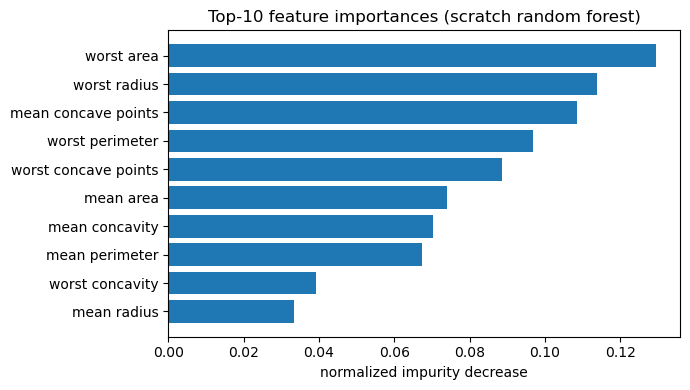

In [5]:
data = load_breast_cancer()
imp = rf.feature_importances_
order = np.argsort(imp)[::-1][:10]

plt.figure(figsize=(7, 4))
plt.barh([data.feature_names[i] for i in order][::-1], imp[order][::-1])
plt.xlabel("normalized impurity decrease")
plt.title("Top-10 feature importances (scratch random forest)")
plt.tight_layout(); plt.show()

## 7c. Demo: regression on Diabetes

Same forest class, only `task="regression"` — the tree now minimizes variance and
leaves predict the mean, while the forest averages instead of voting.

In [6]:
Xr, yr = load_diabetes(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.25, random_state=0)

rfr = RandomForest(n_estimators=300, task="regression", max_depth=None,
                   min_samples_leaf=3, max_features="auto", random_state=0)
rfr.fit(Xtr, ytr)

pred = rfr.predict(Xte)
print(f"OOB  R^2  : {oob_score(rfr, Xtr, ytr):.4f}")
print(f"test R^2  : {r2_score(yte, pred):.4f}")
print(f"test RMSE : {mean_squared_error(yte, pred) ** 0.5:.3f}")

OOB  R^2  : 0.5093
test R^2  : 0.2887
test RMSE : 59.424


## 8. Sanity check against scikit-learn

With matching hyper-parameters, scikit-learn's `RandomForest*` should land in the same
ballpark. Exact equality is not expected — sklearn differs in tie-breaking, threshold
choice, and other details — but close numbers confirm our math.

In [7]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# classification
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.25,
                                              random_state=0, stratify=yc)
skc = RandomForestClassifier(n_estimators=200, max_features="sqrt",
                             random_state=0, oob_score=True).fit(Xc_tr, yc_tr)
print("CLASSIFICATION            scratch     sklearn")
print(f"  OOB accuracy            {oob_score(rf, Xc_tr, yc_tr):.4f}      {skc.oob_score_:.4f}")
print(f"  test accuracy           {accuracy_score(yc_te, rf.predict(Xc_te)):.4f}      {accuracy_score(yc_te, skc.predict(Xc_te)):.4f}")

# regression
skr = RandomForestRegressor(n_estimators=300, max_features=1/3, min_samples_leaf=3,
                            random_state=0, oob_score=True).fit(Xtr, ytr)
print("\nREGRESSION                scratch     sklearn")
print(f"  OOB R^2                 {oob_score(rfr, Xtr, ytr):.4f}      {skr.oob_score_:.4f}")
print(f"  test R^2                {r2_score(yte, rfr.predict(Xte)):.4f}      {r2_score(yte, skr.predict(Xte)):.4f}")

CLASSIFICATION            scratch     sklearn
  OOB accuracy            0.9624      0.9648
  test accuracy           0.9441      0.9441

REGRESSION                scratch     sklearn
  OOB R^2                 0.5093      0.5033
  test R^2                0.2887      0.2924


## Summary

We derived and implemented a random forest end to end:

| Step | Math | Where in code |
|------|------|---------------|
| 1 | Gini $1-\sum p_k^2$ / variance | `DecisionTree._impurity` |
| 2 | impurity decrease $\Delta I$ | `DecisionTree._best_split` |
| 3 | greedy CART growth | `DecisionTree._build` |
| 4 | bootstrap + aggregate | `RandomForest.fit`, `predict` |
| 5 | random subspace $m=\sqrt d$ | `_resolve_max_features`, `max_features` |
| 6 | OOB $\approx 37\%$ | `oob_score`, `oob_indices_` |
| 7 | Gini importances | `feature_importances_` |

The two ideas that make a random forest work, both aimed at **variance**: (1) **bagging**
averages many high-variance trees, killing the $\tfrac{1-\rho}{B}\sigma^2$ term; and
(2) **random feature subspaces** *decorrelate* the trees, lowering $\rho$ and with it the
irreducible $\rho\sigma^2$ floor that bagging alone cannot beat. Bias stays roughly that
of a single deep tree, so the ensemble keeps low bias *and* gains low variance.

Natural extensions: entropy/log-loss splitting, Extra-Trees (random thresholds for even
lower $\rho$), proper categorical-feature handling, permutation importance (less biased
than Gini importance toward high-cardinality features), and parallel tree fitting.